# Trabalho Prático 1 — Compressão de Imagens

Este notebook implementa um pipeline de compressão de imagens. A arquitetura combina duas abordagens clássicas: a exploração da redundância espacial através de predição linear (+redundância psicovisual por meio do DCT) e a redução da redundância de codificação utilizando Huffman.

1. **DCT 8×8 + quantização** explora a redundância psicovisual. Quantizar agressivamente, porém, borra bordas.
2. **Predição linear do resíduo**: recupera exatamente o que a DCT jogou fora, porque o erro espacial é suave e fácil de prever.
3. **Huffman** compactação lossless dos coeficientes do DCT e da predição linear do erro.


## Visão geral do pipeline

**Compressão**

1. Leitura e tratamento para adicionar *padding* caso necessário.
2. DCT em blocos de 8×8 + quantização (tabela do JPEG).
3. DPCM nos coeficientes DC entre blocos vizinhos + varredura em zigue-zague com truncamento do sufixo de zeros.
4. Predição do erro `original − IDCT(quantizado)` e quantização do erro.
5. Huffman dos dois fluxos de inteiros.
6. Empacotamento em arquivo `.compressed` no disco (cabeçalho + tabelas + dado em si).

**Descompressão** =>  o inverso

A intuição desse pipeline é que podemos ser mais agressivos na DCT do que um JPEG, porque o preditor espacial devolve a maior parte da informação de borda. Esse erro tende a ser pequeno, concentrado em poucos valores, e o Huffman aproveita isso.
Em contramão temos dois dados para codificar com o Huffman, gerando dados extras para armazenar.


## Bibliotecas, constantes e imagem de entrada


In [11]:
import os
import struct
import heapq
import numpy as np
import matplotlib.pyplot as plt

# Diretório das imagens.
IMAGE_DIR = "images"

# Altere esta linha para comprimir outra imagem.
IMAGE_PATH = os.path.join(IMAGE_DIR, "cameraman.pgm")
ENCODED_DIR = "saida"
os.makedirs(ENCODED_DIR, exist_ok=True)
ENCODED_PATH = os.path.join(ENCODED_DIR, "comprimido.compressed")

BLOCK = 8
MAGIC = b"ICV1" # Um identificador de arquivo para o formato de compressão.

QS = [
    np.array([
        [16, 11, 10, 16, 24, 40, 51, 61],
        [12, 12, 14, 19, 26, 58, 60, 55],
        [14, 13, 16, 24, 40, 57, 69, 56],
        [14, 17, 22, 29, 51, 87, 80, 62],
        [18, 22, 37, 56, 68, 109, 103, 77],
        [24, 35, 55, 64, 81, 104, 113, 92],
        [49, 64, 78, 87, 103, 121, 120, 101],
        [72, 92, 95, 98, 112, 100, 103, 99],
    ], dtype=np.float64),
    np.array([
        [32, 22, 20, 32, 48, 80, 102, 122],
        [24, 24, 28, 38, 52, 116, 120, 110],
        [28, 26, 32, 48, 80, 114, 138, 112],
        [28, 34, 44, 58, 102, 174, 160, 124],
        [36, 44, 74, 112, 136, 218, 206, 154],
        [48, 70, 110, 128, 162, 208, 226, 184],
        [98, 128, 156, 174, 206, 242, 240, 202],
        [144, 184, 190, 196, 224, 200, 206, 198],
    ], dtype=np.float64),
    np.array([
        [32, 64, 128, 255, 255, 255, 255, 255],
        [64, 128, 128, 255, 255, 255, 255, 255],
        [128, 128, 255, 255, 255, 255, 255, 255],
        [255, 255, 255, 255, 255, 255, 255, 255],
        [255, 255, 255, 255, 255, 255, 255, 255],
        [255, 255, 255, 255, 255, 255, 255, 255],
        [255, 255, 255, 255, 255, 255, 255, 255],
        [255, 255, 255, 255, 255, 255, 255, 255],
    ], dtype=np.float64),
]

DCT_QUALITY = 2     # Qual matriz de quantização usar
RESIDUE_Q = 10       # Quantização do erro (quanto jogar fora na predição do erro)

images/cameraman.pgm: 256×256, dtype=uint8, 65536 pixels, 65536 bytes uncompressed


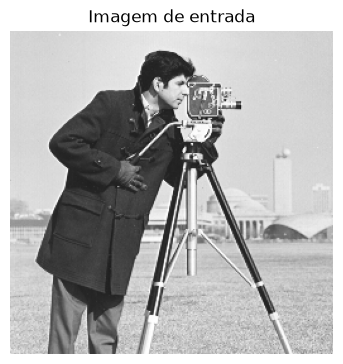

In [12]:

img = plt.imread(IMAGE_PATH)
height, width = img.shape
print(f"{IMAGE_PATH}: {width}×{height}, dtype={img.dtype}, "
      f"{img.size} pixels, {img.size} bytes uncompressed")

plt.figure(figsize=(4.2, 4.2))
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem de entrada")
plt.axis("off")
plt.show()

##  Métricas

- **MSE** e **PSNR** medem a qualidade da reconstrução. Vamos considerar um PSNR > 33 dB como aceitável.
- **Taxa de compressão** = `(H × W)` bytes da imagem bruta / tamanho em disco do aquivo `.compressed`.


In [13]:
def MSE(first, second):
    a = np.asarray(first, dtype=np.float64)
    b = np.asarray(second, dtype=np.float64)
    assert a.shape == b.shape
    return float(np.mean((a - b) ** 2))


def PSNR(first, second, max_pixel=255.0):
    mse = MSE(first, second)
    if mse == 0:
        return float("inf")
    return float(10.0 * np.log10((max_pixel ** 2) / mse))


def image_entropy(hist, tot):
    acc = 0.0
    for val in hist.values():
        p = val / tot
        if p > 0:
            acc += p * np.log2(p)
    return float(-acc)


def mean_huffman_len(hist, huff, tot):
    acc = 0.0
    for key, val in hist.items():
        acc += (val / tot) * len(huff[key])
    return float(acc)

## Huffman

A árvore é construída com um heap de mínimo, na qual, cada símbolo começa como folha, e iterativamente, dois nós de menor frequência viram filhos de um novo nó. O código de cada símbolo é o caminho da raiz até a folha (0 à esquerda, 1 à direita).


In [14]:
def histogram_map(arr):
    flat = np.asarray(arr).ravel().astype(np.int64)
    values, counts = np.unique(flat, return_counts=True)
    return {int(v): int(c) for v, c in zip(values, counts)}


def huffman(hist):
    if not hist:
        return {}
    
    if len(hist) == 1:
        only = next(iter(hist.keys()))
        return {only: "0"}
    
    counter = 0
    queue = []
    for key in sorted(hist.keys()):
        heapq.heappush(queue, (hist[key], counter, [key]))
        counter += 1

    huff_dict = {key: "" for key in hist}

    while len(queue) >= 2:
        val_fr, _, keys_fr = heapq.heappop(queue)
        val_sn, _, keys_sn = heapq.heappop(queue)
        heapq.heappush(queue, (val_fr + val_sn, counter, keys_fr + keys_sn))
        counter += 1
        for k in keys_fr:
            huff_dict[k] += "0"
        for k in keys_sn:
            huff_dict[k] += "1"

    return {key: val[::-1] for key, val in huff_dict.items()}


def encode_symbols(symbols, huff_dict):
    return "".join(huff_dict[int(x)] for x in np.asarray(symbols).ravel())


class Node:
    def __init__(self):
        self.to = [None, None]
        self.end = None # fala se é nó folha e qual símbolo representa


def decode_bits(code, huff_dict):
    root = Node()
    for key, val in huff_dict.items():
        cur = root
        for ch in val:
            idx = 1 if ch == "1" else 0
            if cur.to[idx] is None:
                cur.to[idx] = Node()
            cur = cur.to[idx]
        cur.end = key
    out = []
    cur = root
    for ch in code:
        idx = 1 if ch == "1" else 0
        cur = cur.to[idx]
        if cur.end is not None:
            out.append(cur.end)
            cur = root
    return np.array(out, dtype=np.int32)


# Compressão e descompressão só com Huffman para testar a implementação.
hist_px = histogram_map(img)
huff_px = huffman(hist_px)
code_px = encode_symbols(img, huff_px)
decoded_px = decode_bits(code_px, huff_px).reshape(img.shape)
H = image_entropy(hist_px, img.size)
L = mean_huffman_len(hist_px, huff_px, img.size)
print(f"entropia = {H:.3f}bpp")
print(f"comprimento médio = {L:.3f}bpp")
print(f"eficiência H/L = {H / L:.4f}")
print(f"PSNR={PSNR(img, decoded_px):.4f}dB")
print(f"MSE={MSE(img, decoded_px):.4f}")

entropia = 6.905bpp
comprimento médio = 6.932bpp
eficiência H/L = 0.9960
PSNR=infdB
MSE=0.0000


## DCT 8×8 e quantização

A DCT de um bloco $8×8$ concentra energia no canto superior esquerdo. A tabela de quantização descarta altas frequências, explorando a redundância psicovisual.

- Faço também um fluxo parecido de predição de erro entre coeficientes de blocos consecutivos: o DC atual é substituído por `DC − DC_anterior`. Os DCs são parecidos em regiões homogêneas, então essa diferença é concentrada em um pequeno número de coeficientes, e portanto o Huffman comprime melhor.

- **Zig zag + truncamento** depois da quantização e do zig zag, o sufixo do vetor 64 é quase toda zero. Gravamos `[K, v0, …, vK-1]` em vez de 64 inteiros. Optei por não usar o esquema de comprimento de corrida porque já tinha em mente em usar uma tabela de quantização mais agressiva, gerando um sufixo de zeros grande.


DCT
PSNR=23.61dB
MSE=283.25
Taxa de compressão=6.839


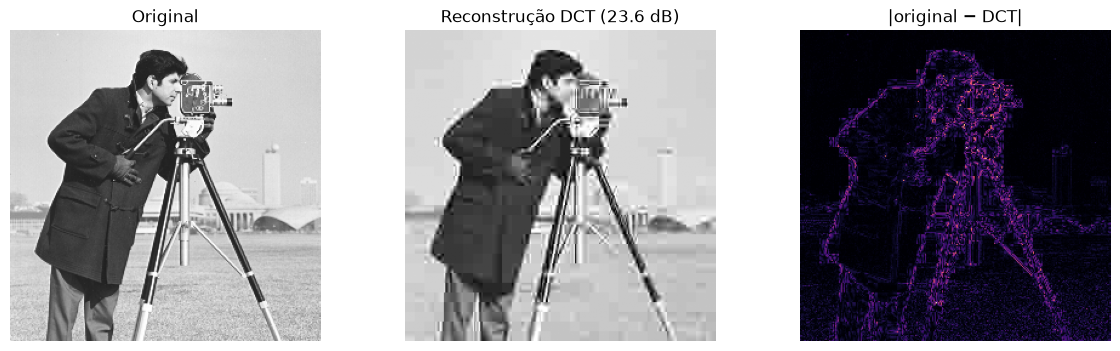

In [15]:
from scipy.fft import dctn, idctn

def pad_image(img, block_size=8):
    h, w = img.shape
    pad_h = (block_size - (h % block_size)) % block_size
    pad_w = (block_size - (w % block_size)) % block_size
    if pad_h == 0 and pad_w == 0:
        return img.astype(np.float64), (h, w)
    padded = np.pad(img.astype(np.float64), ((0, pad_h), (0, pad_w)), mode="edge")
    return padded, (h, w)


def crop_image(img, orig_shape):
    return img[:orig_shape[0], :orig_shape[1]]


def zigzag_coords(n=8):
    lines = [[] for _ in range(2 * n - 1)]
    for i in range(n):
        for j in range(n):
            lines[i + j].append((i, j))
    result = []
    for s, coords in enumerate(lines):
        if s % 2 == 0:
            coords = list(reversed(coords))
        result.extend(coords)
    return result


ZZ = zigzag_coords(8)


def zigzag_scan(block):
    return np.array([block[r, c] for r, c in ZZ], dtype=block.dtype)


def inverse_zigzag(arr):
    block = np.zeros((8, 8), dtype=arr.dtype)
    for idx, (r, c) in enumerate(ZZ):
        if idx < len(arr):
            block[r, c] = arr[idx]
    return block


def encode_block_tail(zz):
    nz = np.nonzero(zz)[0]
    if len(nz) == 0:
        return [0]
    k = int(nz[-1]) + 1
    return [k] + [int(v) for v in zz[:k]]


def decode_block_tail(stream, pos):
    k = int(stream[pos])
    pos += 1
    block = np.zeros(64, dtype=np.int32)
    if k > 0:
        block[:k] = stream[pos:pos + k]
        pos += k
    return block, pos


def DCT(img, quality=1):
    h, w = img.shape
    dct_quant = np.zeros((h, w), dtype=np.int32)
    rec = np.zeros((h, w), dtype=np.float64)
    Qtab = QS[quality]
    for i in range(0, h, BLOCK):
        for j in range(0, w, BLOCK):
            coeffs = dctn(img[i:i+BLOCK, j:j+BLOCK], type=2, norm='ortho')
            quant = np.round(coeffs / Qtab).astype(np.int32)
            dct_quant[i:i+BLOCK, j:j+BLOCK] = quant
            rec[i:i+BLOCK, j:j+BLOCK] = idctn(quant.astype(np.float64) * Qtab, type=2, norm='ortho')
    return dct_quant, rec


def IDCT(dct_quant, quality=1):
    h, w = dct_quant.shape
    rec = np.zeros((h, w), dtype=np.float64)
    Qtab = QS[quality]
    for i in range(0, h, BLOCK):
        for j in range(0, w, BLOCK):
            dequant = dct_quant[i:i+BLOCK, j:j+BLOCK].astype(np.float64) * Qtab
            rec[i:i+BLOCK, j:j+BLOCK] = idctn(dequant, type=2, norm='ortho')
    return rec


padded, orig_shape = pad_image(img)
dct_quant, img_dct = DCT(padded, quality=DCT_QUALITY)
img_dct_view = np.clip(crop_image(img_dct, orig_shape), 0, 255)
print(f"DCT")
print(f"PSNR={PSNR(img, img_dct_view):.2f}dB")
print(f"MSE={MSE(img, img_dct_view):.2f}")
print(f"Taxa de compressão={8.0 / mean_huffman_len(histogram_map(dct_quant), huffman(histogram_map(dct_quant)), dct_quant.size):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].imshow(img, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original")
ax[1].imshow(img_dct_view, cmap="gray", vmin=0, vmax=255)
ax[1].set_title(f"Reconstrução DCT ({PSNR(img, img_dct_view):.1f} dB)")
ax[2].imshow(np.abs(img.astype(float) - img_dct_view), cmap="magma")
ax[2].set_title("|original − DCT|")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

## Predição linear do erro



DCT + predição do erro
PSNR=39.56dB
MSE=7.19
fração de erros nulos: 51.9%


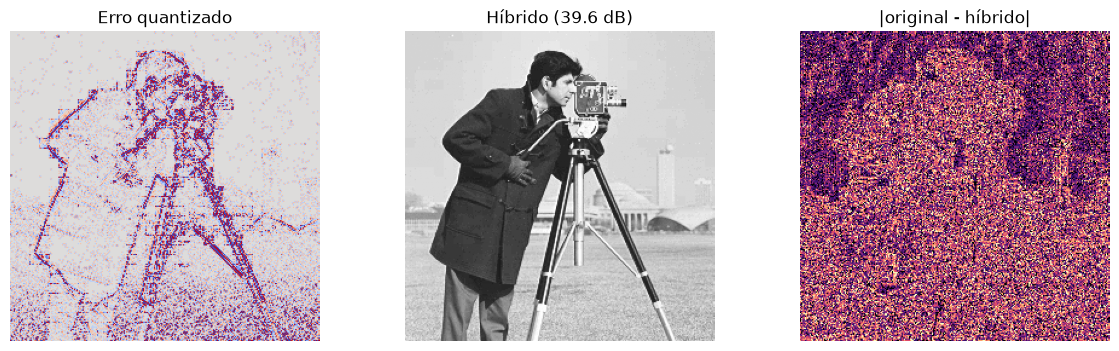

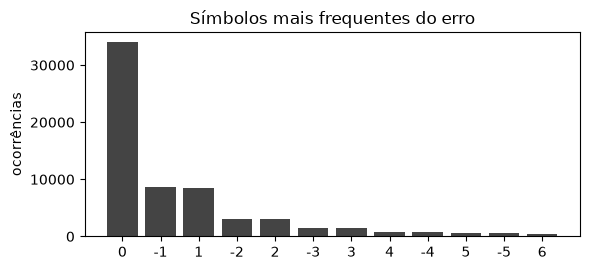

In [16]:
def quantize_predict(img, dct_img, Q=8):
    h, w = img.shape
    qerr = np.zeros((h, w), dtype=np.int32)
    rec = np.zeros((h, w), dtype=np.float64)
    rec_img = np.zeros((h, w), dtype=np.float64)
    target = img.astype(np.float64) - dct_img.astype(np.float64)
    for i in range(h):
        for j in range(w):
            if i == 0 and j == 0:
                pred = 0.0
            elif i == 0:
                pred = rec[i, j - 1]
            elif j == 0:
                pred = rec[i - 1, j]
            else:
                pred = rec[i - 1, j] + rec[i, j - 1] - rec[i - 1, j - 1]
            q = int(np.round((target[i, j] - pred) / Q))
            qerr[i, j] = q
            rec[i, j] = q * Q + pred
            rec_img[i, j] = rec[i, j] + dct_img[i, j]
    return qerr, np.clip(rec_img, 0, 255)


def dequantize_predict(qerr, dct_img, Q=8):
    h, w = qerr.shape
    rec = np.zeros((h, w), dtype=np.float64)
    rec_img = np.zeros((h, w), dtype=np.float64)
    for i in range(h):
        for j in range(w):
            if i == 0 and j == 0:
                pred = 0.0
            elif i == 0:
                pred = rec[i, j - 1]
            elif j == 0:
                pred = rec[i - 1, j]
            else:
                pred = rec[i - 1, j] + rec[i, j - 1] - rec[i - 1, j - 1]
            rec[i, j] = qerr[i, j] * Q + pred
            rec_img[i, j] = rec[i, j] + dct_img[i, j]
    return np.clip(rec_img, 0, 255).astype(np.uint8)


qerr, img_hybrid = quantize_predict(padded, img_dct, Q=RESIDUE_Q)
img_hybrid_view = crop_image(img_hybrid, orig_shape).astype(np.uint8)
print(f"DCT + predição do erro")
print(f"PSNR={PSNR(img, img_hybrid_view):.2f}dB")
print(f"MSE={MSE(img, img_hybrid_view):.2f}")
print(f"fração de erros nulos: {(qerr == 0).mean() * 100:.1f}%")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].imshow(crop_image(qerr, orig_shape), cmap="coolwarm", vmin=-4, vmax=4)
ax[0].set_title("Erro quantizado")
ax[1].imshow(img_hybrid_view, cmap="gray", vmin=0, vmax=255)
ax[1].set_title(f"Híbrido ({PSNR(img, img_hybrid_view):.1f} dB)")
ax[2].imshow(np.abs(img.astype(float) - img_hybrid_view), cmap="magma")
ax[2].set_title("|original - híbrido|")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

# Histograma do erro: poucos símbolos -> Huffman mais eficiente
hist_res_demo = histogram_map(qerr)
syms = sorted(hist_res_demo, key=hist_res_demo.get, reverse=True)[:12]
plt.figure(figsize=(6, 2.8))
plt.bar([str(s) for s in syms], [hist_res_demo[s] for s in syms], color="#444")
plt.title("Símbolos mais frequentes do erro")
plt.ylabel("ocorrências")
plt.tight_layout()
plt.show()

## Formato do arquivo `compressed`

Bits viram bytes (`pack_bits`) e a tabela guarda `(símbolo int16, comprimento, bits)`.


In [17]:
def pack_bits(bitstring):
    nbits = len(bitstring)
    pad = (8 - nbits % 8) % 8
    bitstring = bitstring + ("0" * pad)
    out = bytearray(int(bitstring[i:i+8], 2) for i in range(0, len(bitstring), 8))
    return bytes(out), nbits


def unpack_bits(data, nbits):
    return "".join(f"{b:08b}" for b in data)[:nbits]


def write_huff_table(fh, huff):
    items = sorted(huff.items())
    fh.write(struct.pack(">H", len(items)))
    for symbol, code in items:
        n = len(code)
        packed, _ = pack_bits(code)
        fh.write(struct.pack(">hB", int(symbol), n))
        fh.write(packed[:(n + 7) // 8])


def read_huff_table(fh):
    (n_items,) = struct.unpack(">H", fh.read(2))
    huff = {}
    for _ in range(n_items):
        symbol, n = struct.unpack(">hB", fh.read(3))
        raw = fh.read((n + 7) // 8)
        huff[int(symbol)] = unpack_bits(raw, n) if n else "0"
    return huff


def write_file(path, payload):
    with open(path, "wb") as fh:
        fh.write(MAGIC)
        H, W = payload["padded_shape"]
        oh, ow = payload["orig_shape"]
        fh.write(struct.pack(">HHHHBB", oh, ow, H, W, payload["quality"], payload["Q"]))
        write_huff_table(fh, payload["huff_dct"])
        dct_bytes, n_dct = pack_bits(payload["code_dct"])
        fh.write(struct.pack(">I", n_dct))
        fh.write(dct_bytes)
        write_huff_table(fh, payload["huff_res"])
        res_bytes, n_res = pack_bits(payload["code_res"])
        fh.write(struct.pack(">I", n_res))
        fh.write(res_bytes)


def read_file(path):
    with open(path, "rb") as fh:
        if fh.read(4) != MAGIC:
            raise ValueError("arquivo ICV inválido")
        oh, ow, H, W, quality, Q = struct.unpack(">HHHHBB", fh.read(10))
        huff_dct = read_huff_table(fh)
        (n_dct,) = struct.unpack(">I", fh.read(4))
        code_dct = unpack_bits(fh.read((n_dct + 7) // 8), n_dct)
        huff_res = read_huff_table(fh)
        (n_res,) = struct.unpack(">I", fh.read(4))
        code_res = unpack_bits(fh.read((n_res + 7) // 8), n_res)
    return {
        "code_dct": code_dct, "huff_dct": huff_dct,
        "code_res": code_res, "huff_res": huff_res,
        "padded_shape": (H, W), "orig_shape": (oh, ow),
        "quality": quality, "Q": Q,
    }

## Pipeline completo

- Comprimir
- Salvar 
- Ler 
- Reconstruir



In [18]:
def compress(img, quality=1, Q=8):
    padded_img, orig_shape = pad_image(img, 8)
    H, W = padded_img.shape
    dct_q, rec_dct = DCT(padded_img, quality=quality)

    dct_ints = []
    prev_dc = 0
    for i in range(0, H, BLOCK):
        for j in range(0, W, BLOCK):
            zz = zigzag_scan(dct_q[i:i+BLOCK, j:j+BLOCK]).astype(np.int32)
            dc = int(zz[0])
            zz[0] = dc - prev_dc
            prev_dc = dc
            dct_ints.extend(encode_block_tail(zz))
    dct_flat = np.array(dct_ints, dtype=np.int32)

    qerr, rec_img = quantize_predict(padded_img, rec_dct, Q)
    res_flat = qerr.flatten()

    hist_dct = histogram_map(dct_flat)
    huff_dct = huffman(hist_dct)
    code_dct = encode_symbols(dct_flat, huff_dct)

    hist_res = histogram_map(res_flat)
    huff_res = huffman(hist_res)
    code_res = encode_symbols(res_flat, huff_res)

    return {
        "code_dct": code_dct, "huff_dct": huff_dct,
        "code_res": code_res, "huff_res": huff_res,
        "padded_shape": (H, W), "orig_shape": orig_shape,
        "quality": quality, "Q": Q,
        "rec_dct": rec_dct, "qerr": qerr, "rec_img": rec_img,
        "hist_dct": hist_dct, "hist_res": hist_res,
        "dct_flat": dct_flat, "res_flat": res_flat,
    }


def decompress(data):
    H, W = data["padded_shape"]
    dct_flat = decode_bits(data["code_dct"], data["huff_dct"])
    dct_q = np.zeros((H, W), dtype=np.int32)
    pos = 0
    prev_dc = 0
    for i in range(0, H, BLOCK):
        for j in range(0, W, BLOCK):
            zz, pos = decode_block_tail(dct_flat, pos)
            zz[0] = int(zz[0]) + prev_dc
            prev_dc = int(zz[0])
            dct_q[i:i+BLOCK, j:j+BLOCK] = inverse_zigzag(zz)
    rec_dct = IDCT(dct_q, quality=data["quality"])
    qerr = decode_bits(data["code_res"], data["huff_res"]).reshape(H, W)
    final = dequantize_predict(qerr, rec_dct, data["Q"])
    return crop_image(final, data["orig_shape"])


def compress_to_file(img, path, quality=1, Q=8):
    data = compress(img, quality=quality, Q=Q)
    persist = {k: data[k] for k in (
        "code_dct", "huff_dct", "code_res", "huff_res",
        "padded_shape", "orig_shape", "quality", "Q",
    )}
    write_file(path, persist)
    data["file_size"] = os.path.getsize(path)
    data["path"] = path
    return data


def decompress_from_file(path):
    """Descompressão a partir do arquivo em disco"""
    return decompress(read_file(path))

caminho: saida/comprimido.compressed
taxa : 2.77
MSE: 7.190
PSNR: 39.56dB


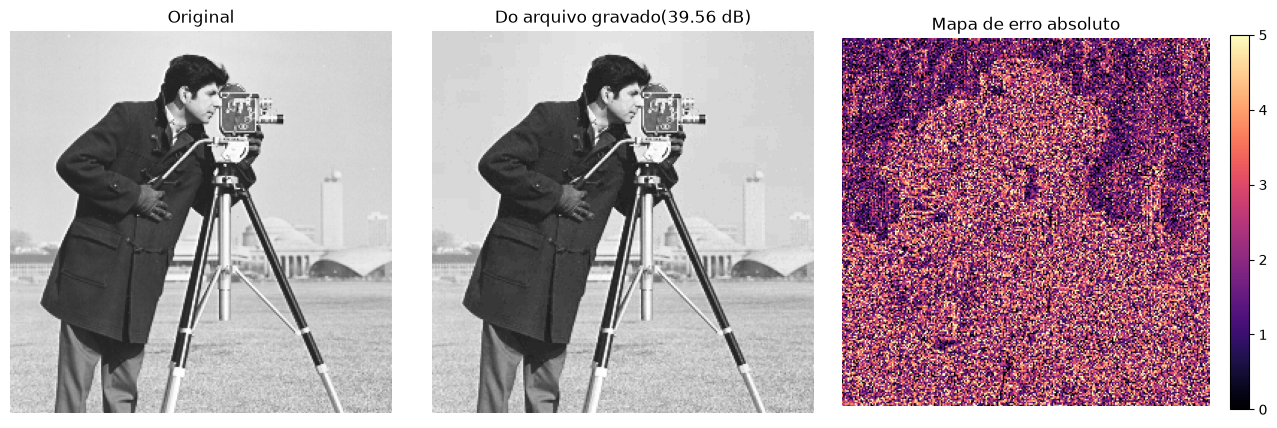

In [19]:
data = compress_to_file(img, ENCODED_PATH, quality=DCT_QUALITY, Q=RESIDUE_Q)
recon = decompress_from_file(ENCODED_PATH)

orig_bytes = int(img.size)
comp_bytes = os.path.getsize(ENCODED_PATH)
ratio = orig_bytes / comp_bytes
bpp = 8.0 / ratio
psnr_val = PSNR(img, recon)
mse_val = MSE(img, recon)

print(f"caminho: {ENCODED_PATH}")
print(f"taxa : {ratio:.2f}")
print(f"MSE: {mse_val:.3f}")
print(f"PSNR: {psnr_val:.2f}dB")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[1].imshow(recon, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Do arquivo gravado({psnr_val:.2f} dB)")
im = axes[2].imshow(np.abs(img.astype(float) - recon.astype(float)), cmap="magma")
axes[2].set_title("Mapa de erro absoluto")
for a in axes:
    a.axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()

## Alguns testes

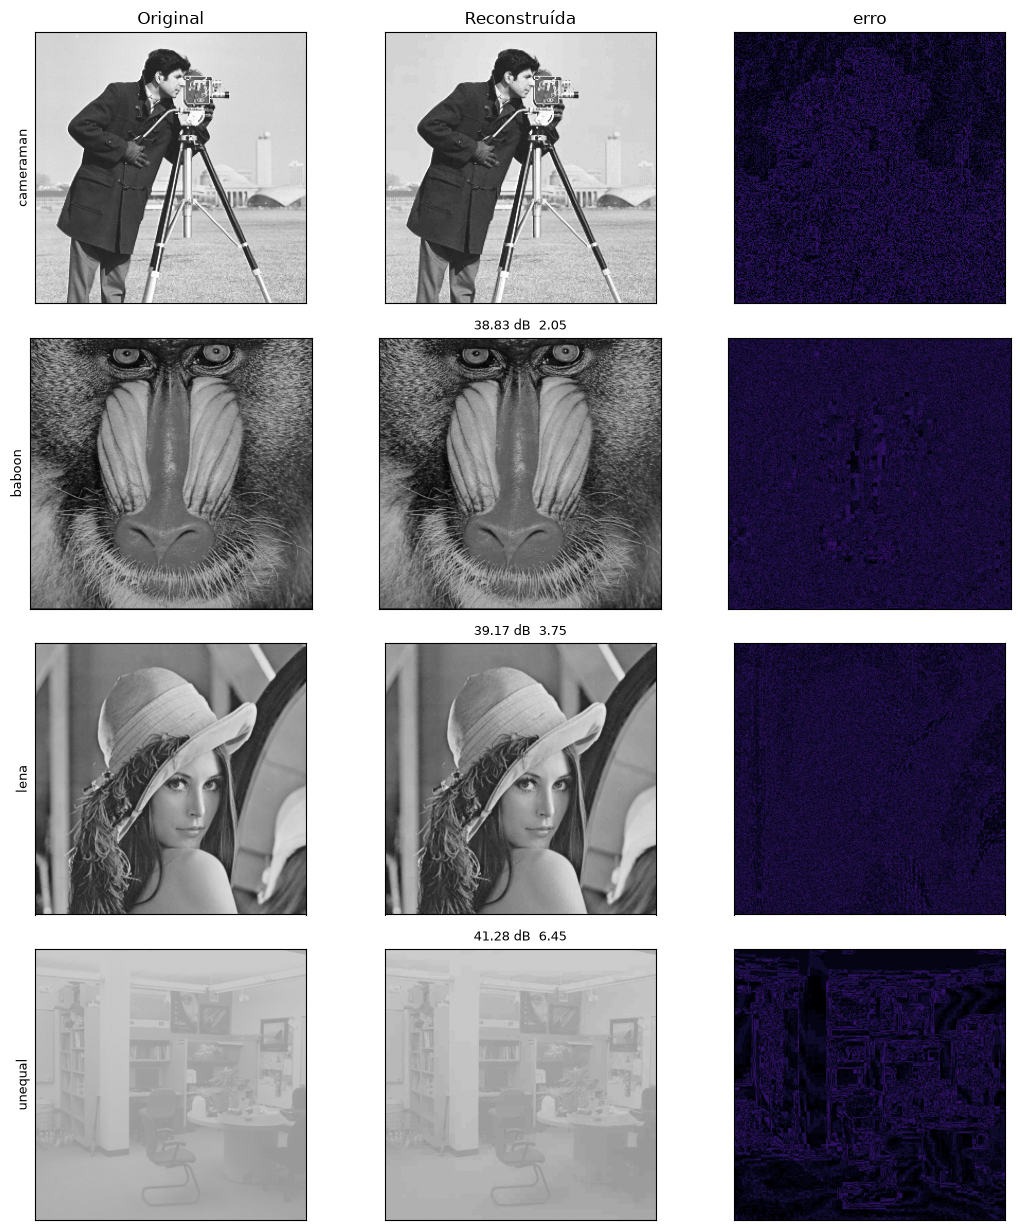

imagem	 PSNR dB	 taxa

cameraman.pgm	 39.56337498191346	 2.772015903899839
baboon.pgm	 38.83016646115058	 2.0533880903490758
lena.pgm	 39.174655956336345	 3.74839493815686
unequal.pgm	 41.27627501765435	 6.4456350964831


In [20]:
TEST_NAMES = ["cameraman.pgm", "baboon.pgm", "lena.pgm", "unequal.pgm"]

rows = []
fig, axes = plt.subplots(len(TEST_NAMES), 3, figsize=(11, 3.1 * len(TEST_NAMES)))
if len(TEST_NAMES) == 1:
    axes = np.array([axes])

for r, name in enumerate(TEST_NAMES):
    path = os.path.join(IMAGE_DIR, name)
    if not os.path.exists(path):
        continue

    im = plt.imread(path)
    out_path = os.path.join(ENCODED_DIR, name.replace(".pgm", ".compressed"))
    compress_to_file(im, out_path, quality=DCT_QUALITY, Q=RESIDUE_Q)
    rec = decompress_from_file(out_path)
    psnr = PSNR(im, rec)
    ratio = im.size / os.path.getsize(out_path)
    bpp = 8.0 / ratio
    rows.append((name, psnr, ratio))

    axes[r, 0].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[r, 0].set_ylabel(name.replace(".pgm", ""), fontsize=9)
    axes[r, 1].imshow(rec, cmap="gray", vmin=0, vmax=255)
    axes[r, 1].set_title(f"{psnr:.2f} dB  {ratio:.2f}", fontsize=9)
    axes[r, 2].imshow(np.abs(im.astype(float) - rec.astype(float)), cmap="magma", vmin=0, vmax=25)
    for c in range(3):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
axes[0, 0].set_title("Original")
axes[0, 1].set_title("Reconstruída")
axes[0, 2].set_title("erro")
plt.tight_layout()
plt.show()

print(f"{'imagem'}\t {'PSNR dB'}\t {'taxa'}")
print()
for name, psnr, ratio in rows:
    print(f"{name}\t {psnr}\t {ratio}")

## Conclusões

- **baboon** é o pior caso: textura de alta frequência. A DCT quantiza pouco nesses blocos (muitos AC sobrevivem).
- **unequal** é o melhor caso: baixo contraste e espacialmente suave. Presumo que a DCT quantiza muito, e o preditor recupera quase tudo.

Os parâmetros `DCT_QUALITY` e `RESIDUE_Q` são o controle de quão comprimido-boa qualidade: aumentar `RESIDUE_Q` (o quanto joga fora na predição do erro) ou `DCT_QUALITY` (a agressividade da tabela) aumenta a taxa e mas diminui o PSNR. 
